# 단일 경계 모델 (NSW 시뮬레이터 v3) — 코드 노트북

> 3조 후반부 · 2026-06-04 · 핵심 모듈 `nsw_simulator_v3.py`
>
> 노인 지하철 요금 부과의 **사회후생(NSB)** 을 계산하는 단일 경계 모델입니다.
> 이 노트북은 모듈을 그대로 import해 **항상 최신 코드와 동기화**되며, 두 버전(연령 단일 / 소득 단일)을 실행해 결과를 보여줍니다.

## 목적함수 (통행분해, 2026-06 재설계 · 팀 통일)
통행을 **필수(생계·의료, 비탄력)** 와 **재량(쇼핑·여가, 탄력)** 으로 나눕니다.
$$\text{NSB} = \sum_g\big(\text{복지편익}_g + \text{운임수익}_g\big)$$
- 운임수익 $R_g$ = (필수 + 잔류 재량 탑승) × 요금
- 복지편익 $W_g$ = (현행무임 전체 탑승 × κ_freq) − 복지손실 ; 복지손실 = 줄어든 재량 탑승 × κ_freq + 외출 포기분 × κ_act
- ρ = f/f₀, φ(ρ) = |ε_E|ρ + (1−|ε_E|ρ)|ε_I|ρ (1인 재량 탑승 손실 비율)
- 복지편익 단가: **탑승당 KOTI κ** (의료230+사회100=κ_freq, 우울322+자살617=κ_act, 2014→CPI)
- **목적함수는 NSB(복지편익+운임수익)** — 세민 다구간 모델과 동일 정의. (현행무임 대비 ΔW는 NSB−baseline이라 최적해 동일)


In [1]:
# === 환경 설정 ===
%matplotlib inline
import sys, inspect
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
for fp in [r"C:\Windows\Fonts\malgun.ttf", "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if Path(fp).exists():
        font_manager.fontManager.addfont(fp); rcParams["font.family"] = font_manager.FontProperties(fname=fp).get_name(); break
rcParams["axes.unicode_minus"] = False

# 모듈 import (같은 폴더의 nsw_simulator_v3.py)
sys.path.insert(0, str(Path.cwd()))
import nsw_simulator_v3 as m
from nsw_simulator_v3 import (Calibration, Policy, load_demographics, load_demand,
    evaluate_policy, baseline_loss, cpi_factor,
    generate_age_single_grid, generate_income_single_grid, simulate_2026_2050)
print("모듈 로드 완료:", m.__file__)

모듈 로드 완료: D:\지우지마세요\Documents\Claude\Projects\머신러닝 강의\notebooks\nsw_simulator\nsw_simulator_v3.py


## 1. 파라미터 (Calibration 기본값)

In [2]:
cal = Calibration()
print(f"σ (재량 통행 비중)   = {cal.discretionary_share}")
print(f"ε_intensive (빈도)   = {cal.epsilon_intensive}")
print(f"ε_extensive (외출포기) = {cal.epsilon_extensive}")
print(f"기본요금 f0          = {cal.base_fare_2026:,}원")
print(f"κ_freq(2025) = {cal.kappa_freq(2025):,.0f}원/탑승  (의료+사회)")
print(f"κ_act (2025) = {cal.kappa_act(2025):,.0f}원/탑승  (우울+자살, 외출포기분)")

σ (재량 통행 비중)   = 0.62
ε_intensive (빈도)   = -0.3
ε_extensive (외출포기) = -0.05
기본요금 f0          = 1,550원
κ_freq(2025) = 411원/탑승  (의료+사회)
κ_act (2025) = 1,170원/탑승  (우울+자살, 외출포기분)


## 2. 핵심 코드 — 행동 모듈 & 목적함수
실제 구현을 그대로 표시합니다(모듈 동기화).

In [3]:
print(inspect.getsource(m.behavior_module_v3))

def behavior_module_v3(
    n_persons_gu: float,
    avg_trips_per_person: float,
    n_trips_total_gu: float,
    policy: Policy,
    q_value: float,
    cal: Calibration,
    lam: float | None = None,
) -> dict:
    """행동 모듈 (2026-06 통행분해 재설계).

    통행을 '필수(생계·의료)'와 '재량(쇼핑·여가 등)'으로 분리 (σ = discretionary_share).
      - 필수 통행 (1-σ): 요금 내도 유지(비탄력) → 운임수익 기여, 복지손실 0.
      - 재량 통행 (σ):   ε로 줄어듦.
          외출 자체 포기(extensive): 비율 d_E = |ε_E|·ρ
          빈도 감소(intensive):      배수 m_I = 1 + ε_I·ρ (계속 외출하는 사람)
      ρ = f/f₀ (부과요금/기본요금).

    줄어든 재량 통행 = 외출포기분 + 빈도감소분 (배타적 분할 → 이중계상 없음).
    유지 탑승(운임수익 base) = 필수 + 잔류 재량.
    """
    if lam is None:
        lam = get_lambda(cal, policy.income_rule)
    f = policy.fare_level
    f0 = cal.base_fare_2026
    rho = (f / f0) if f0 else 0.0
    sigma = cal.discretionary_share

    # 사람 단위
    n_persons_keep_free = n_persons_gu * q_value
    n_persons_pay_before = n_persons_gu * (1 - q_value)

    # 유료 전환자의 총 탑승 (기간), 시장 총량으로 상한
    trips_pay_tota

In [4]:
print(inspect.getsource(m.nsw_module_v3))

def nsw_module_v3(
    behavior: dict,
    n_persons_gu: float,
    policy: Policy,
    cal: Calibration,
    sim_year: int = 2025,
) -> dict:
    """사회후생 산출 (2026-06 통행분해 재설계).

    [목적함수 NSB = 복지편익 + 운임수익]  (팀 공통, 세민 다구간과 동일 정의)
       복지편익 = 현행무임 baseline(전체 탑승×κ_freq) − 복지손실 ; 조립은 evaluate_policy에서.
    [운임수익] R = n_trips_pay_after × f          (유지 탑승 = 필수 + 잔류 재량)
       f = fare_level × CPI(2026→t)  ← [통일] 요금도 시점 CPI 보정(다구간·κ와 시점 일치).
         행동반응 ρ=f/f₀는 실질 부담비율이라 명목값(fare_level) 그대로 사용.
    [복지손실] L = forgone_dis × κ_freq(t)          (줄어든 재량 탑승의 건강·사회 편익)
                + forgone_ext × κ_act(t)           (외출 자체 포기분의 정신건강 편익)
       κ_freq=(의료+사회)×CPI, κ_act=(우울+자살)×CPI. 생계 통행은 손실 0.
       빈도만 줄인 탑승(forgone_int)은 외출은 유지 → 정신건강(κ_act) 손실 없음.
    (참고) ΔW = R − L = NSB − baseline (현행무임 대비 변화; 최적 정책은 NSB와 동일).

    단위: 운임·복지손실 모두 「탑승 기간 단위」 → evaluate_policy에서 year_factor로 동시 연 환산.
    """
    kf = cal.kappa_freq(sim_year)
    ka = cal.kappa_act(sim_year)
    f = policy.fare_leve

## 3. 베이스라인 검증 (현행 무임 손실 재현)

In [5]:
df23 = load_demand(year_filter=[2023])
bl = baseline_loss(df23, cal, sim_year=2023)
print(f"노인 무임 탑승:  {bl['n_elderly_total']:,.0f}")
print(f"계산 손실:       {bl['calculated_loss_eok']:,.1f}억원")
print(f"공시 손실(1~8호선): {bl['public_loss_eok']:,}억원   일치(±5%): {'O' if bl['match'] else 'X'}")

노인 무임 탑승:  220,940,635
계산 손실:       3,663.2억원
공시 손실(1~8호선): 3,663억원   일치(±5%): O


## 4. 정책 평가 헬퍼 (그리드 → 결과표 + 프론티어)

In [6]:
df = load_demand(year_filter=[2025])

def eval_grid(policies):
    rows = [evaluate_policy(df, p, demog, cal, sim_year=2025) for p in policies]
    keep = ["policy_label","q_avg","revenue_eok_yearly","welfare_eok_yearly","nsb_eok_yearly"]
    return pd.DataFrame([{k:r[k] for k in keep} for r in rows]).sort_values("nsb_eok_yearly", ascending=False).reset_index(drop=True)

def show(res, title):
    t = res.head(6).copy(); t["q(%)"]=(t["q_avg"]*100).round(1)
    display(t[["policy_label","q(%)","revenue_eok_yearly","welfare_eok_yearly","nsb_eok_yearly"]])
    fig, ax = plt.subplots(figsize=(8.4,5))
    ax.scatter(res["q_avg"]*100, res["nsb_eok_yearly"], s=80, c=res["nsb_eok_yearly"], cmap="viridis", edgecolors="black", lw=0.4)
    ax.axvline(50, color="grey", ls="--", lw=1, alpha=0.6, label="수용성 q=50%")
    for _,r in res.head(6).iterrows():
        ax.annotate(r["policy_label"], (r["q_avg"]*100, r["nsb_eok_yearly"]), fontsize=7.5, xytext=(4,3), textcoords="offset points")
    ax.set_xlabel("수용성 q (무임 유지 노인 %)"); ax.set_ylabel("NSB (억원/연)")
    ax.set_title(title, fontweight="bold"); ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

demog = load_demographics()
print("준비 완료")

준비 완료


## 5. 버전 1 — 연령 단일 기준
소득 무관, 연령 임계 × 요금. "특정 연령 미만은 요금, 이상은 무임".

,policy_label,q(%),revenue_eok_yearly,welfare_eok_yearly,nsb_eok_yearly
0,"80↑·전면·1,550원",22.3,2253.161080,762.744837,3015.905918
1,"80↑·전면·1,400원",22.3,2084.654349,784.160513,2868.814862
2,"75↑·전면·1,550원",40.7,1718.376678,816.803517,2535.180195
3,"80↑·전면·1,050원",22.3,1651.492736,834.651831,2486.144567
4,"75↑·전면·1,400원",40.7,1589.864767,833.136214,2423.000981
5,"75↑·전면·1,050원",40.7,1259.513413,871.643493,2131.156906


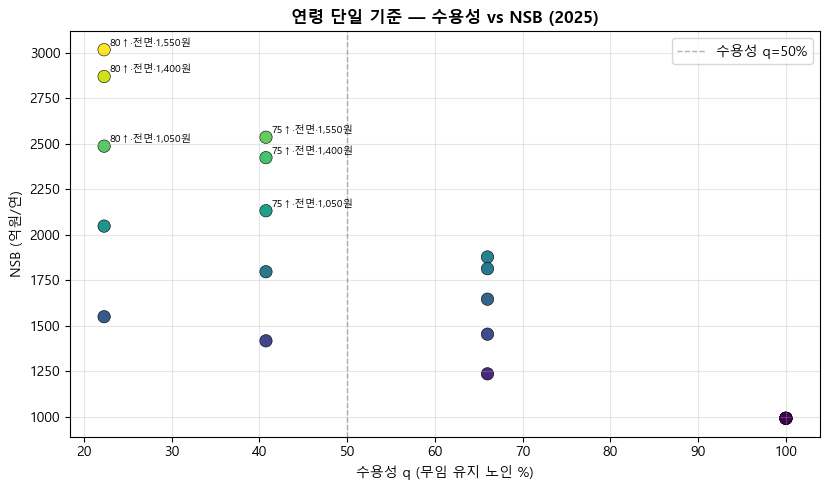

In [7]:
res_age = eval_grid(generate_age_single_grid())
show(res_age, "연령 단일 기준 — 수용성 vs NSB (2025)")

## 6. 버전 2 — 소득 단일 기준
연령 65+ 고정, 소득 규칙 × 요금. "소득 취약층은 무임, 그 외 요금".

,policy_label,q(%),revenue_eok_yearly,welfare_eok_yearly,nsb_eok_yearly
0,"65↑·기초생활·1,550원",10.8,2590.395993,728.655447,3319.051441
1,"65↑·기초생활·1,400원",10.8,2396.668539,753.276448,3149.944987
2,"65↑·기초생활·1,050원",10.8,1898.674802,811.324898,2709.999699
3,"65↑·국민연금비수급·1,550원",40.1,1754.777277,813.123963,2567.901240
4,"65↑·국민연금비수급·1,400원",40.1,1623.543081,829.802637,2453.345718
5,65↑·기초생활·700원,10.8,1334.632456,870.212576,2204.845032


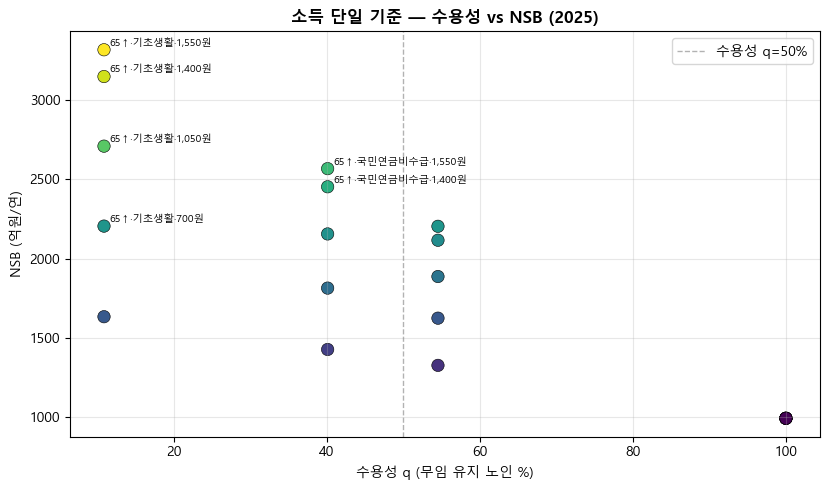

In [8]:
res_inc = eval_grid(generate_income_single_grid())
show(res_inc, "소득 단일 기준 — 수용성 vs NSB (2025)")

## 7. 미래 시뮬레이션 (2026~2050)
권고 정책(65↑·기초연금하위70%·1,550)을 전반부 예측 수요 + 추계인구로 전 연도 평가.

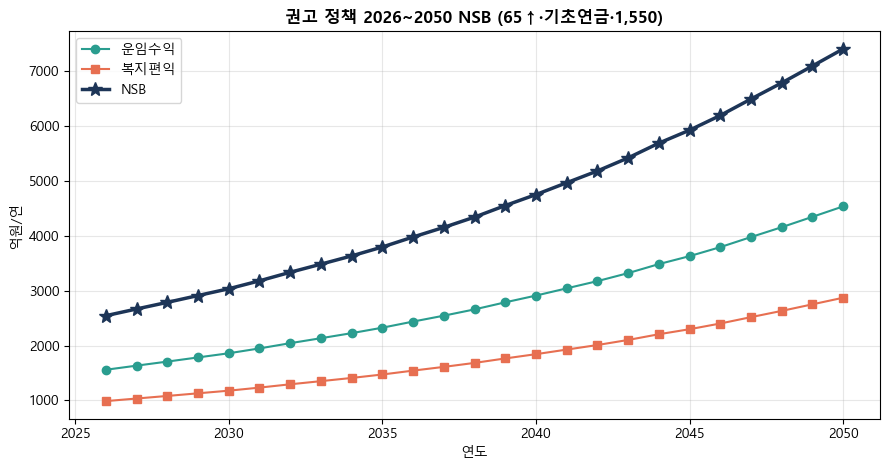

,sim_year,senior_pop_total,revenue_eok_yearly,welfare_eok_yearly,nsb_eok_yearly
0,2026,1940214,1558.727938,986.554697,2545.282634
9,2035,2488933,2326.131375,1472.261950,3798.393325
24,2050,2947063,4538.759744,2872.685242,7411.444986


In [9]:
try:
    fut = simulate_2026_2050(Policy(65,"basic_pension",1550), demog, cal)
    fig, ax = plt.subplots(figsize=(9,4.8))
    ax.plot(fut["sim_year"], fut["revenue_eok_yearly"], "o-", label="운임수익", color="#2A9D8F")
    ax.plot(fut["sim_year"], fut["welfare_eok_yearly"], "s-", label="복지편익", color="#E76F51")
    ax.plot(fut["sim_year"], fut["nsb_eok_yearly"], "*-", lw=2.5, ms=10, label="NSB", color="#1D3557")
    ax.set_xlabel("연도"); ax.set_ylabel("억원/연"); ax.set_title("권고 정책 2026~2050 NSB (65↑·기초연금·1,550)", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
    display(fut[fut["sim_year"].isin([2026,2035,2050])][["sim_year","senior_pop_total","revenue_eok_yearly","welfare_eok_yearly","nsb_eok_yearly"]])
except Exception as e:
    print("미래 입력 파일 미가용 — 스킵:", e)

## 8. 요약 & 한계
- **목적함수**: **NSB = 복지편익 + 운임수익** (탑승당 KOTI κ, 수송원가·재정이전 제외). 세민 다구간 모델과 동일 정의.
- **행동반응**: ε(빈도 −0.3, 외출포기 −0.05)를 **재량 통행에만** 적용. 생계 통행 비탄력.
- **두 버전**: 연령 단일 / 소득 단일을 별도 그리드로 평가(`generate_age_single_grid`·`generate_income_single_grid`).
- **시 단위 접근**: `load_demographics()`는 자치구별 수급률을 **인구가중평균(기초연금 약 54.5%)** 으로 합산한 시 단위 1개 항목으로 제공(자치구별 모델링 미사용). 선형 목적함수라 자치구 합산과 NSB·최적정책 동일(`by_gu=True`로 자치구판 확인 가능).
- **결과**: 유료 정책일수록 NSB↑, 요금 상한이 최적(코너해), q가 수용성↔후생 trade-off. σ 0.50~0.74·ε 전 구간 강건.
- **한계**: κ는 KOTI 2014(노인 한정 직접추정 부재). σ=0.62(개인용무 절반 가정). 최적해가 코너라 수용성·형평성 제약을 정책 판단에 병행.
